In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# set up given values
distance = np.array([3.1, 5.0, 6.5, 8.0, 9.9, 11.5, 13.1, 14.8, 16.4, 18.0, 19.7])
time = np.array([1.912, 3.043, 3.948, 4.921, 5.908, 6.288, 6.678, 7.060, 7.442, 7.830, 8.212])

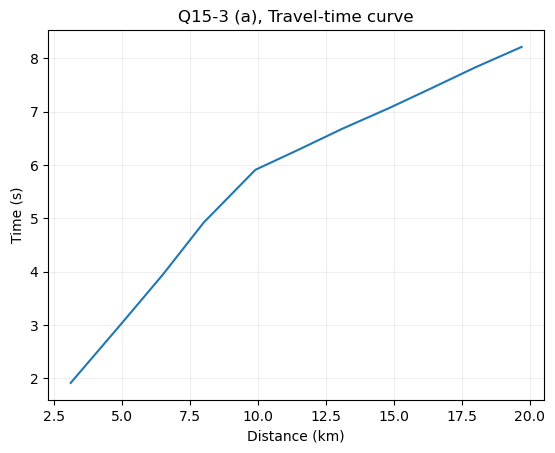

In [34]:
#part a
plt.title("Q15-3 (a), Travel-time curve")
plt.ylabel("Time (s)")
plt.xlabel("Distance (km)")
plt.grid(True, alpha=0.2)
plt.plot(distance, time)

In [35]:
#part b
# first layer (direct wave)
d1 = distance[:5]
t1 = time[:5]

slope1, intercept1 = np.polyfit(d1, t1, 1)
v1 = 1 / slope1

# second layer (refracted wave)
d2 = distance[6:]
t2 = time[6:]

slope2, intercept2 = np.polyfit(d2, t2, 1)
v2 = 1 / slope2

print("Layer 1 velocity:", v1, "km/s")
print("Layer 2 velocity:", v2, "km/s")

Layer 1 velocity: 1.683797261543338 km/s
Layer 2 velocity: 4.2737758571383155 km/s


In [43]:
# fit refracted arrivals
slope2, intercept2 = np.polyfit(d2, t2, 1)

print("slope2:", slope2)
print("intercept2:", intercept2)

# intercept time
ti = intercept2
print("t_i:", ti)

slope2: 0.23398513011152428
intercept2: 3.6070438661709994
t_i: 3.6070438661709994


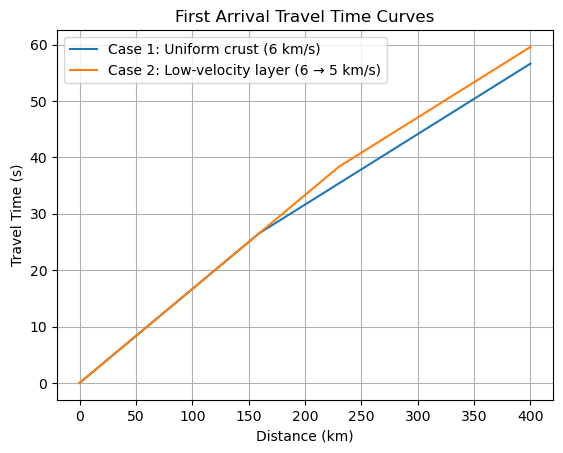

In [45]:
# Q15-4
# Model parameters

# Velocities (km/s)
v1 = 6.0   # upper crust
v2 = 5.0   # low velocity layer
vm = 8.0   # mantle

# Thicknesses (km)
h_crust = 30.0   # single crust thickness (case 1)
h1 = 20.0        # upper crust thickness (case 2)
h2 = 10.0        # lower crust thickness (case 2)

# Distance range (km)
x = np.linspace(0, 400, 1000)

# CASE 1: Homogeneous crust (6 km/s) over mantle

# Direct wave
t_direct1 = x / v1

# Critical angle
ic1 = np.arcsin(v1 / vm)

# Intercept time
ti1 = (2 * h_crust * np.cos(ic1)) / v1

# Refracted mantle wave
t_refr1 = x / vm + ti1

# First arrival
t_first_case1 = np.minimum(t_direct1, t_refr1)

# CASE 2: Low velocity layer
# 20 km (6 km/s) over 10 km (5 km/s) over mantle

# Direct wave
t_direct2 = x / v1

# Critical condition at mantle
ic3 = np.arcsin(v2 / vm)

# Ray parameter
p = np.sin(ic3) / vm

# Angles in upper layers using Snell's law
i1 = np.arcsin(v1 * p)
i2 = np.arcsin(v2 * p)

# Intercept time through two layers
ti2 = 2 * (h1 * np.cos(i1) / v1 + h2 * np.cos(i2) / v2)

# Refracted mantle wave
t_refr2 = x / vm + ti2

# First arrival
t_first_case2 = np.minimum(t_direct2, t_refr2)


# Plot results

plt.figure()

plt.plot(x, t_first_case1, label="Case 1: Uniform crust (6 km/s)")
plt.plot(x, t_first_case2, label="Case 2: Low-velocity layer (6 → 5 km/s)")

plt.xlabel("Distance (km)")
plt.ylabel("Travel Time (s)")
plt.title("First Arrival Travel Time Curves")

plt.legend()
plt.grid(True)

plt.show()